**Nhóm 67 | Ngôn ngữ Lập trình Python**
#LƯU Ý: Để Folder Project trong mục MyDrive của Google Drive để sử dụng

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#TẠO CẤU TRÚC THƯ MỤC

In [3]:
from pathlib import Path

BASE = Path("/content/drive/MyDrive/Project") # Định nghĩa đường dẫn gốc

dirs = ["data/raw", "data/processed", "notebooks", "src", "results", "report"] # Tạo một danh sách các tên thư mục con cần được tạo
for d in dirs:
    (BASE / d).mkdir(parents=True, exist_ok=True) # Duyệt qua từng tên thư mục và tạo nó.
print("✅ Da tao cau truc thu muc")

requirements = """datasets
pandas
matplotlib
seaborn
"""
(BASE / "requirements.txt").write_text(requirements, encoding="utf-8") # Tạo một tệp 'requirements.txt'
print("✅ Da tao requirements.txt")

✅ Da tao cau truc thu muc
✅ Da tao requirements.txt


# SAO CHÉP THƯ MỤC

In [4]:
from google.colab import auth
from googleapiclient.discovery import build

auth.authenticate_user()
service = build('drive', 'v3')

# ── Đổi 2 dòng này ───────────────────────────────────────────
FOLDER_ID = "1gls6W3W3ESMOY1wkWi8dchm8gEDUYqWh"   # ID folder được chia sẻ
DEST_DIR  = "/content/drive/MyDrive/Project"      # lưu về đây
# ─────────────────────────────────────────────────────────────

import os
os.makedirs(DEST_DIR, exist_ok=True)

def copy_folder(folder_id, local_path):
    results = service.files().list(
        q=f"'{folder_id}' in parents",
        fields="files(id, name, mimeType)"
    ).execute()

    for item in results.get('files', []):
        name     = item['name']
        item_id  = item['id']
        mime     = item['mimeType']
        dst_path = os.path.join(local_path, name)

        if mime == 'application/vnd.google-apps.folder':
            # Là thư mục → đệ quy
            os.makedirs(dst_path, exist_ok=True)
            copy_folder(item_id, dst_path)
        else:
            # Là file → tải về
            content = service.files().get_media(fileId=item_id).execute()
            with open(dst_path, 'wb') as f:
                f.write(content)
            print(f"✓ {name}")

copy_folder(FOLDER_ID, DEST_DIR)
print(f"\n✓ Xong → {DEST_DIR}")

✓ mbpp_50.json
✓ submissions_50_v2.json
✓ submissions_50_v2.json
✓ hidden_v2.json
✓ mbpp_clean.json
✓ All_Run_final.ipynb
✓ 03_simulate_v2.ipynb
✓ 01_eda_v2.ipynb
✓ 06_baseline.ipynb
✓ 04_visualize_v3.ipynb
✓ 02_runner_v2.ipynb
✓ 05_comparison.ipynb
✓ 00_setup.ipynb
✓ generate_plots.cpython-312.pyc
✓ comparison_3sets.cpython-312.pyc
✓ error_stats.cpython-312.pyc
✓ run_grading_v2.cpython-312.pyc
✓ run_baseline.cpython-312.pyc
✓ simulate_v2.cpython-312.pyc
✓ runner_v2.cpython-312.pyc
✓ runner_v2.cpython-313.pyc
✓ error_stats.cpython-313.pyc
✓ run_baseline.cpython-313.pyc
✓ comparison_3sets.cpython-313.pyc
✓ simulate_v2.cpython-313.pyc
✓ compare_test_sets.cpython-313.pyc
✓ runner.cpython-312.pyc
✓ generate_plots.cpython-313.pyc
✓ regenerate_all.cpython-313.pyc
✓ runner.cpython-313.pyc
✓ run_grading_v2.py
✓ regenerate_all.py
✓ generate_plots.py
✓ run_baseline.py
✓ error_stats.py
✓ simulate_v2.py
✓ runner_v2.py
✓ comparison_3sets.py
✓ requirements.txt

✓ Xong → /content/drive/MyDrive/Projec

#KIỂM TRA THƯ MỤC

In [5]:
from pathlib import Path

BASE = Path("/content/drive/MyDrive/Project") # Định nghĩa đường dẫn gốc của dự án

files_to_check = [
    BASE / "src" / "runner_v2.py",
    BASE / "data" / "raw" / "mbpp_50.json",
]

all_ok = True # Biến theo dõi xem tất cả các tệp có tồn tại không
for path in files_to_check:
    if path.exists(): # Kiểm tra xem tệp có tồn tại tại tại đường dẫn đã cho không
        print(f"  ✓ {path}") # Nếu tồn tại, in ra dấu '✓' và đường dẫn của tệp
    else:
        print(f"  ✗ Thiếu: {path}") # Nếu không tồn tại, in ra dấu '✗' và thông báo thiếu tệp
        all_ok = False

if all_ok:
    print("\n✓ Đã đủ file cần thiết") # Nếu tất cả các tệp đều tồn tại, in thông báo thành công
else:
    print("\n❌ Thiếu file — hãy kiểm tra thư mục dự án trên Drive") # Nếu có tệp bị thiếu, in thông báo lỗi

  ✓ /content/drive/MyDrive/Project/src/runner_v2.py
  ✓ /content/drive/MyDrive/Project/data/raw/mbpp_50.json

✓ Đã đủ file cần thiết


#KIỂM TRA

In [6]:
import sys
from pathlib import Path

BASE = Path("/content/drive/MyDrive/Project") # Định nghĩa lại đường dẫn gốc
sys.path.insert(0, str(BASE / "src")) # Thêm thư mục 'src' của dự án

checks = {
    "runner.py": BASE / "src" / "runner_v2.py", # Đường dẫn đến tệp 'runner.py'
    "mbpp_50.json": BASE / "data" / "raw" / "mbpp_50.json", # Đường dẫn đến tệp 'mbpp_subset.json'
}
all_ok = True
for name, path in checks.items():
    ok = path.exists()
    icon = "✓" if ok else "✗"
    print(f"  {icon} {name}")
    if not ok:
        all_ok = False
# Kiểm tra runner
try:
    from runner_v2 import grade_submission
    print("  ✓ runner.py import được")
except Exception as e:
    print(f"  ✗ Lỗi import runner: {e}")
    all_ok = False

if all_ok:
    print("\n✅ Môi trường sẵn sàng — chuyển sang notebook 01")
else:
    print("\n❌ Có lỗi — kiểm tra lại các bước trên")

  ✓ runner.py
  ✓ mbpp_50.json
  ✓ runner.py import được

✅ Môi trường sẵn sàng — chuyển sang notebook 01


#ĐỌC DỮ LIỆU

In [7]:
import os
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Auto-resolve relative path to Project directory
BASE = Path("/content/drive/MyDrive/Project")

DATA_FILE = BASE / 'data' / 'processed' / 'hidden_v2.json'
print(f"Loading data from relative path: {DATA_FILE}")

with open(DATA_FILE, encoding='utf-8') as f:
    problems = json.load(f)

print(f"✓ Doc xong: {len(problems)} bai toan")

Loading data from relative path: /content/drive/MyDrive/Project/data/processed/hidden_v2.json
✓ Doc xong: 50 bai toan


#THỐNG KÊ BỘ DỮ LIỆU

In [8]:
# Tao DataFrame de phan tich
df = pd.DataFrame(problems)
df['num_public_tests'] = df['public_tests'].apply(len)
df['num_hidden_tests'] = df['hidden_tests'].apply(len)
df['desc_word_count'] = df['text'].apply(lambda x: len(x.split()))
df['code_line_count'] = df['code'].apply(lambda x: len(x.strip().split('\n')))

print("=============================================================")
print("  BANG THONG KE MO TA BO DU LIEU MBPP_50")
print("=============================================================")
print(f"  Tong so bai toan               : {len(df)}")
print(f"  Phan bo chu de (Topic distribution):")
for topic, count in df['topic'].value_counts().items():
    print(f"    - {topic:<15} : {count} bai")
print(f"  So public tests trung binh/bai : {df['num_public_tests'].mean():.1f} (min={df['num_public_tests'].min()}, max={df['num_public_tests'].max()})")
print(f"  So hidden tests trung binh/bai : {df['num_hidden_tests'].mean():.1f} (min={df['num_hidden_tests'].min()}, max={df['num_hidden_tests'].max()})")
print(f"  Do dai mo ta trung binh (tu)  : {df['desc_word_count'].mean():.1f}")
print(f"  Do dai code mau trung binh (dong): {df['code_line_count'].mean():.1f}")
print("=============================================================")

  BANG THONG KE MO TA BO DU LIEU MBPP_50
  Tong so bai toan               : 50
  Phan bo chu de (Topic distribution):
    - list            : 20 bai
    - string          : 16 bai
    - math            : 14 bai
  So public tests trung binh/bai : 3.0 (min=3, max=3)
  So hidden tests trung binh/bai : 8.0 (min=6, max=10)
  Do dai mo ta trung binh (tu)  : 14.4
  Do dai code mau trung binh (dong): 2.8


#PHÂN BỔ TOPICS

/tmp/ipykernel_12995/3172274579.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='topic', palette='viridis')


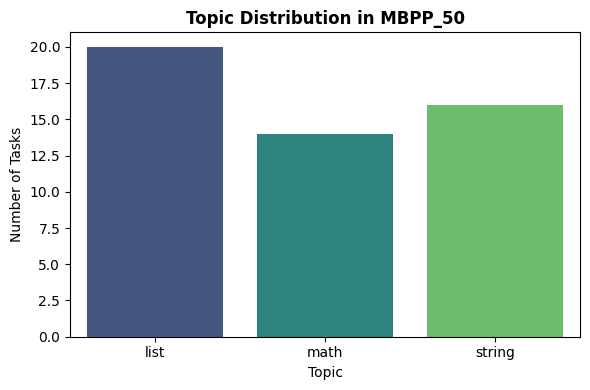

In [9]:
# Ve bieu do phan bo topic
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='topic', palette='viridis')
plt.title("Topic Distribution in MBPP_50", fontsize=12, fontweight='bold')
plt.xlabel("Topic")
plt.ylabel("Number of Tasks")
plt.tight_layout()
os.makedirs(BASE / 'results', exist_ok=True)
plt.savefig(BASE / 'results' / 'topic_distribution.png', dpi=300)
plt.show()

#ĐỌC CẤU TRÚC BÀI NỘP

In [10]:
import os
import json
import sys
from pathlib import Path

# Auto-resolve relative path to Project directory
BASE = Path("/content/drive/MyDrive/Project")

# Thêm thư mục src vào sys.path để import module
sys.path.insert(0, str(BASE / 'src'))
import simulate_v2

# 1. Khai báo đường dẫn tới file submission_50.json
json_file_path = BASE/'data' / 'processed' / 'submissions_50_v2.json'

print(f"Đang kiểm tra file: {json_file_path}")

# 2. Đọc và check file
if json_file_path.exists():
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

        print("Đã đọc file thành công! Cấu trúc dữ liệu:")
        # In thử một phần dữ liệu ra màn hình để kiểm tra (dùng indent để dễ nhìn)
        # Giới hạn in 500 ký tự đầu để tránh trôi màn hình nếu file quá dài
        preview = json.dumps(data, indent=4, ensure_ascii=False)
        print(preview[:500] + "\n... [ĐÃ CẮT BỚT] ...\n")
else:
    print(f"LỖI: Không tìm thấy file tại {json_file_path}")



Đang kiểm tra file: /content/drive/MyDrive/Project/data/processed/submissions_50_v2.json
Đã đọc file thành công! Cấu trúc dữ liệu:
[
    {
        "submission_id": "SV001",
        "task_id": 1,
        "func_name": "sum_list",
        "topic": "list",
        "error_type": "WA",
        "submitted_code": "def sum_list(lst):\n    total=0\n    for i in range(len(lst)):\n        total+=i\n    return total\n",
        "note": "Cộng index thay vì giá trị — WA với mọi input"
    },
    {
        "submission_id": "SV002",
        "task_id": 1,
        "func_name": "sum_list",
        "topic": "list",
        "error_type": "WA",
 
... [ĐÃ CẮT BỚT] ...



#MÔ PHỎNG 1 PHẦN BÀI NỘP MẪU

In [11]:
# Load va hien thi mot vai bai nop mau
SUB_FILE = BASE / 'data' / 'processed' / 'submissions_50_v2.json'
with open(SUB_FILE, encoding='utf-8') as f:
    subs = json.load(f)

print(f"✓ Da load {len(subs)} bai nop sinh vien mo phong.")
print("\nHanh vi bai nop mau:")
for sub in subs[:3]:
    print(f" - ID: {sub['submission_id']} | Task: {sub['task_id']} | Error Type: {sub['error_type']}")
    print(f"   Mo ta: {sub['note']}")
    print(f"   Ma nguon:")
    print(sub['submitted_code'])
    print("-" * 50)

✓ Da load 50 bai nop sinh vien mo phong.

Hanh vi bai nop mau:
 - ID: SV001 | Task: 1 | Error Type: WA
   Mo ta: Cộng index thay vì giá trị — WA với mọi input
   Ma nguon:
def sum_list(lst):
    total=0
    for i in range(len(lst)):
        total+=i
    return total

--------------------------------------------------
 - ID: SV002 | Task: 1 | Error Type: WA
   Mo ta: Quên return — trả None
   Ma nguon:
def sum_list(lst):
    total=0
    for x in lst:
        total+=x

--------------------------------------------------
 - ID: SV003 | Task: 1 | Error Type: HC
   Mo ta: Hard-code kết quả bài test đầu tiên
   Ma nguon:
def sum_list(lst):
    if lst==[1,2,3]: return 6
    if lst==[10,20,30]: return 60
    return 0

--------------------------------------------------


#TẠO MÔ PHỎNG

In [12]:
import os
import json
import sys
from pathlib import Path

# Auto-resolve relative path to Project directory
BASE = Path("/content/drive/MyDrive/Project")

sys.path.insert(0, str(BASE / 'src'))
import simulate_v2

print("Dang chay mo phong sinh vien v2...")
simulate_v2.generate()


Dang chay mo phong sinh vien v2...
Dang doc du lieu tu /content/drive/MyDrive/Project/data/raw/submissions_50_v2.json...
OK: Da sao chep 50 bai nop tu raw sang processed -> /content/drive/MyDrive/Project/data/processed/submissions_50_v2.json
  AC: 5 bai nop
  CE: 1 bai nop
  HC: 2 bai nop
  RE: 4 bai nop
  WA: 38 bai nop
  Task IDs (42 tasks): 1 -> 50


#KIỂM TRA ĐƯỜNG DẪN

In [13]:
import os
import sys
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
from pathlib import Path

# Auto-resolve BASE
BASE = Path("/content/drive/MyDrive/Project")

sys.path.insert(0, str(BASE / 'src'))

print(f'✓ BASE = {BASE}')
print(f'✓ Dataset: {(BASE / "data" / "processed" / "hidden_v2.json").exists()}')
print(f'✓ runner_v2.py: {(BASE / "src" / "runner_v2.py").exists()}')
print(f'✓ run_baseline.py: {(BASE / "src" / "run_baseline.py").exists()}')

✓ BASE = /content/drive/MyDrive/Project
✓ Dataset: True
✓ runner_v2.py: True
✓ run_baseline.py: True


#CHẠY BASELINE

In [14]:
import run_baseline

# Chạy baseline và lưu kết quả
run_baseline.main()

  CHẠY BASELINE — Code chuẩn trên 50 bài toán
  Dataset: hidden_v2.json  |  Luồng song song: 8

  ✓ Đã load 50 bài toán
  → Mỗi bài: 3 public + 6 hidden tests

  Bắt đầu chạy song song (8 luồng)...

  [✓] Task  5 count_char                     pub=3/3 hid=6/6 lat=0.2762s
  [✓] Task  3 reverse_string                 pub=3/3 hid=6/6 lat=0.2844s
  [✓] Task  2 is_even                        pub=3/3 hid=6/6 lat=0.3107s
  [✓] Task  1 sum_list                       pub=3/3 hid=6/6 lat=0.3207s
  [✓] Task  8 remove_duplicates              pub=3/3 hid=7/7 lat=0.2891s
  [✓] Task  7 is_palindrome                  pub=3/3 hid=7/7 lat=0.3036s
  [✓] Task  6 factorial                      pub=3/3 hid=7/7 lat=0.3071s
  [✓] Task  4 find_max                       pub=3/3 hid=8/8 lat=0.3045s
  [✓] Task 11 is_prime                       pub=3/3 hid=7/7 lat=0.3166s
  [✓] Task 12 sum_even                       pub=3/3 hid=7/7 lat=0.3394s
  [✓] Task  9 average                        pub=3/3 hid=7/7 lat=0.3722

#LOAD VÀ HIỂN THỊ KẾT QUẢ

In [15]:
# Load kết quả baseline
df_bl = pd.read_csv(BASE / 'results' / 'baseline_summary.csv')

print(f'Số bài toán: {len(df_bl)}')
print(f'Baseline OK (pass 100%): {df_bl["baseline_ok"].sum()}/{len(df_bl)}')
print(f'\nLatency public trung bình : {df_bl["pub_latency"].mean():.4f}s/test')
print(f'Latency hidden trung bình  : {df_bl["hid_latency"].mean():.4f}s/test')
print(f'Latency tổng trung bình    : {df_bl["avg_latency_total"].mean():.4f}s/test')
print()

# Hiển thị bảng
display(df_bl[['task_id', 'func_name', 'topic', 'pub_pass', 'pub_total', 'hid_pass', 'hid_total', 'baseline_ok', 'avg_latency_total']].head(10))

Số bài toán: 50
Baseline OK (pass 100%): 50/50

Latency public trung bình : 0.3544s/test
Latency hidden trung bình  : 0.3601s/test
Latency tổng trung bình    : 0.3573s/test



,task_id,func_name,topic,pub_pass,pub_total,hid_pass,hid_total,baseline_ok,avg_latency_total
0,1,sum_list,list,3,3,6,6,True,0.3207
1,2,is_even,math,3,3,6,6,True,0.3107
2,3,reverse_string,string,3,3,6,6,True,0.2844
3,4,find_max,list,3,3,8,8,True,0.3045
4,5,count_char,string,3,3,6,6,True,0.2762
5,6,factorial,math,3,3,7,7,True,0.3071
6,7,is_palindrome,string,3,3,7,7,True,0.3036
7,8,remove_duplicates,list,3,3,7,7,True,0.2891
8,9,average,math,3,3,7,7,True,0.3722
9,10,to_uppercase,string,3,3,7,7,True,0.3645


#KIỂM TRA BÀI FAIL

In [16]:
# Tìm bài bị fail
df_fail = df_bl[df_bl['baseline_ok'] == False]

if len(df_fail) == 0:
    print('✅ Tất cả 50 bài đều PASS — Bộ test case hợp lệ hoàn toàn!')
else:
    print(f'⚠️ Có {len(df_fail)} bài FAIL — Cần kiểm tra test case!')
    display(df_fail[['task_id', 'func_name', 'topic', 'pub_tpr', 'hid_tpr', 'pub_WA', 'hid_WA', 'pub_RE', 'hid_RE']])

✅ Tất cả 50 bài đều PASS — Bộ test case hợp lệ hoàn toàn!


#PHÂN TÍCH LATENCY THEO TOPICS

In [17]:
# Phân tích latency theo chủ đề
lat_by_topic = df_bl.groupby('topic')['avg_latency_total'].agg(['mean', 'min', 'max', 'std']).round(4)
lat_by_topic.columns = ['Trung bình (s)', 'Min (s)', 'Max (s)', 'Std (s)']
print('Latency theo chủ đề bài toán:')
display(lat_by_topic)

Latency theo chủ đề bài toán:


,Trung bình (s),Min (s),Max (s),Std (s)
topic,,,,
list,0.3444,0.2107,0.5166,0.0829
math,0.3630,0.2598,0.5322,0.0904
string,0.3682,0.2762,0.5878,0.0922


#CHẠY CHẤM MÔ PHỎNG

In [18]:
import sys
import os
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BASE = Path('/content/drive/MyDrive/Project')
sys.path.insert(0, str(BASE / 'src'))
os.chdir(BASE)

# ✅ Đã sửa: dùng import thay vì exec() để tránh namespace pollution
import run_grading_v2
run_grading_v2.main()


  CHẠY CHẤM BÀI TỰ ĐỘNG V2
  Bộ test: 3 public + 6-10 hidden (Phân bố Chuông)

  ✓ Đã load 50 bài nộp mô phỏng
  ✓ Đã load 50 bài toán MBPP
  ✓ Số bài sẽ chấm: 50/50

  Bắt đầu chấm (sử dụng psutil giới hạn tài nguyên và thu thập lỗi)...

  Chấm xong 10/50 bài...
  Chấm xong 20/50 bài...
  Chấm xong 30/50 bài...
  Chấm xong 40/50 bài...
  Chấm xong 50/50 bài...
  ✓ Lưu CSV: /content/drive/MyDrive/Project/results/error_analysis_v2.csv
  ✓ Lưu JSON (Đầy đủ traceback): /content/drive/MyDrive/Project/results/error_analysis_v2.json

  KẾT QUẢ CHẤM BÀI V2 (Set 3: Bell Curve)
  Tổng submissions        : 50
  Public Test Leakage Rate: 30.0% (15 bài)
  Avg TPR public (3 test) : 58.67%
  Avg TPR hidden (10 test): 54.23%
  Latency public          : 0.0466s/test
  Latency hidden          : 0.0471s/test

  Lỗi PUBLIC  → SE:3  WA:57  RE:2  TLE:0  MLE:0
  Lỗi HIDDEN  → SE:6  WA:158  RE:11  TLE:0  MLE:0

  Theo topic:
    list      : 21 bài, Leakage Rate=28.6%
    math      : 16 bài, Leakage Rate=31.2

#BIỂU ĐỒ LATENCY BASELINE VÀ BÀI NỘP SINH VIÊN

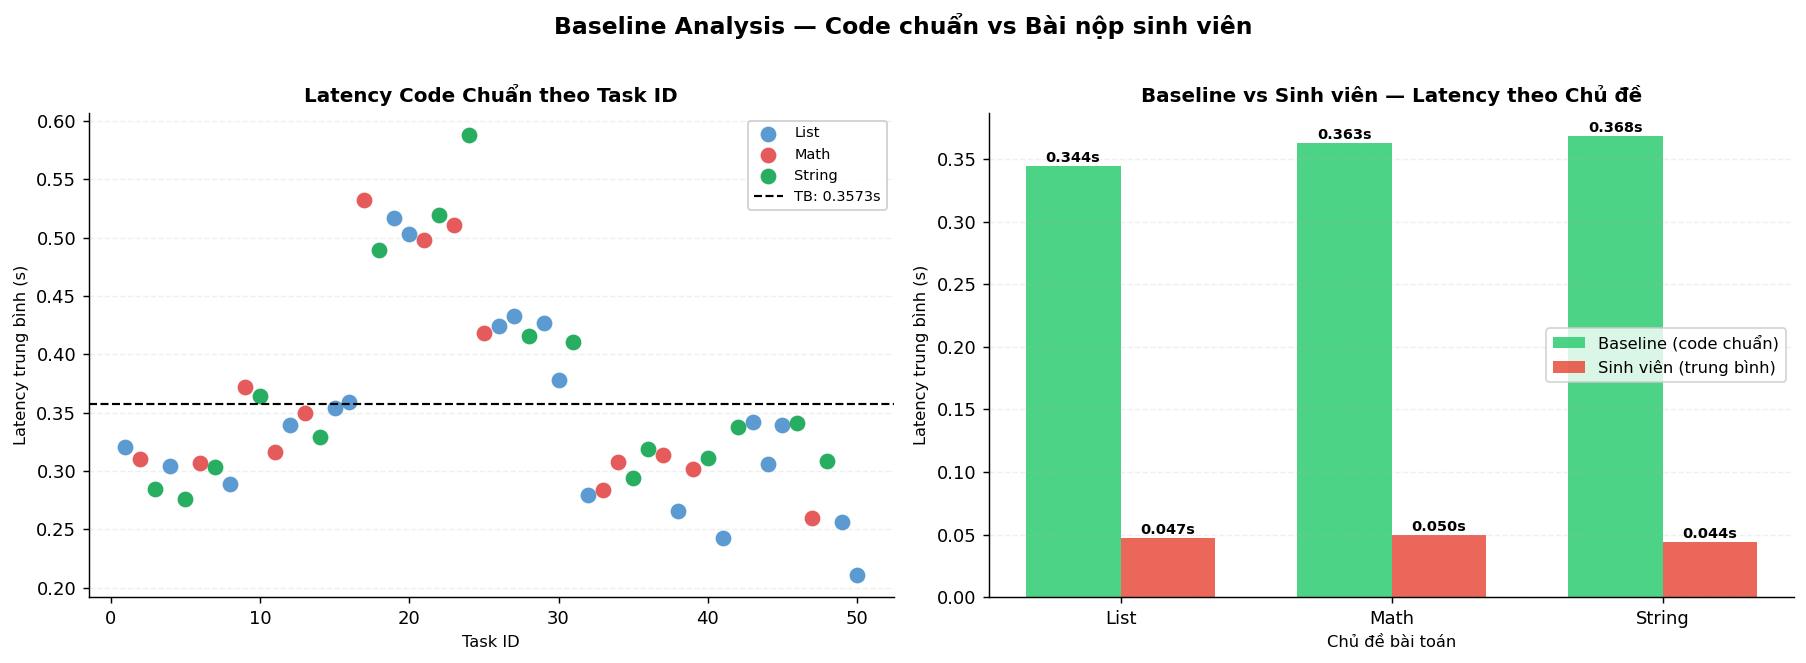

✓ Đã lưu biểu đồ: /content/drive/MyDrive/Project/results/baseline_latency.png


In [19]:
# Load kết quả grading của sinh viên để so sánh
student_csv = BASE / 'results' / 'error_analysis_v2.csv'
has_student = student_csv.exists()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=130)
fig.suptitle('Baseline Analysis — Code chuẩn vs Bài nộp sinh viên', fontsize=13, fontweight='bold', y=1.01)

colors = {'list': '#5C9BD1', 'math': '#E55B5B', 'string': '#27AE60'}

# ── Chart 1: Latency baseline từng bài theo topic ──────────────────────────
ax1 = axes[0]
for topic, grp in df_bl.groupby('topic'):
    ax1.scatter(grp['task_id'], grp['avg_latency_total'],
                label=topic.capitalize(), color=colors.get(topic, '#888'),
                s=60, zorder=3)

avg_lat = df_bl['avg_latency_total'].mean()
ax1.axhline(avg_lat, color='black', linestyle='--', linewidth=1.2,
            label=f'TB: {avg_lat:.4f}s', zorder=4)
ax1.set_title('Latency Code Chuẩn theo Task ID', fontsize=11, fontweight='bold')
ax1.set_xlabel('Task ID', fontsize=9)
ax1.set_ylabel('Latency trung bình (s)', fontsize=9)
ax1.legend(fontsize=8, framealpha=0.9)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis='y', alpha=0.2, linestyle='--')

# ── Chart 2: So sánh latency baseline vs sinh viên ─────────────────────────
ax2 = axes[1]
if has_student:
    df_sv = pd.read_csv(student_csv)
    # Tính latency trung bình theo topic cho sinh viên
    sv_lat_col = 'avg_latency_hid' if 'avg_latency_hid' in df_sv.columns else 'avg_latency_pub'
    sv_lat_by_topic = df_sv.groupby('topic')[sv_lat_col].mean()
    bl_lat_by_topic = df_bl.groupby('topic')['avg_latency_total'].mean()

    topics = sorted(df_bl['topic'].unique())
    x = np.arange(len(topics))
    w = 0.35

    bars1 = ax2.bar(x - w/2,
                    [bl_lat_by_topic.get(t, 0) for t in topics],
                    w, label='Baseline (code chuẩn)', color='#2ECC71', alpha=0.85)
    bars2 = ax2.bar(x + w/2,
                    [sv_lat_by_topic.get(t, 0) for t in topics],
                    w, label='Sinh viên (trung bình)', color='#E74C3C', alpha=0.85)

    for bar in list(bars1) + list(bars2):
        h = bar.get_height()
        if h > 0:
            ax2.text(bar.get_x() + bar.get_width()/2, h + 0.001,
                     f'{h:.3f}s', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax2.set_xticks(x)
    ax2.set_xticklabels([t.capitalize() for t in topics])
    ax2.legend(fontsize=9)
else:
    ax2.text(0.5, 0.5, 'Chưa có file\nerror_analysis_v2.csv\n\nChạy run_grading_v2.py trước',
             ha='center', va='center', fontsize=11, color='gray',
             transform=ax2.transAxes)

ax2.set_title('Baseline vs Sinh viên — Latency theo Chủ đề', fontsize=11, fontweight='bold')
ax2.set_xlabel('Chủ đề bài toán', fontsize=9)
ax2.set_ylabel('Latency trung bình (s)', fontsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.2, linestyle='--')

plt.tight_layout()
out_path = BASE / 'results' / 'baseline_latency.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Đã lưu biểu đồ: {out_path}')

#ĐO LATENCY/SUBMISSION VÀ P95

In [20]:
import time, csv, statistics, tempfile, shutil, subprocess, sys, os
from pathlib import Path

BASE = Path("/content/drive/MyDrive/Project")
sys.path.insert(0, str(BASE / 'src'))
from runner_v2 import grade_submission

import json
with open(BASE / 'data' / 'processed' / 'submissions_50_v2.json', encoding='utf-8') as f:
    subs = json.load(f)
with open(BASE / 'data' / 'processed' / 'hidden_v2.json', encoding='utf-8') as f:
    tasks = {t['task_id']: t for t in json.load(f)}

print(f"Đo latency trên {len(subs)} bài nộp...")
print("=" * 60)

rows = []
for s in subs:
    task = tasks.get(s['task_id'])
    if not task:
        continue
    tests = task['public_tests'] + task['hidden_tests']

    t0 = time.perf_counter()
    result = grade_submission(s['submitted_code'], s['func_name'], tests, 'all')
    total_lat = round(time.perf_counter() - t0, 4)
    avg_per_test = round(result['avg_latency'], 4)

    print(f"  [{s['submission_id']}] {s['func_name']:<25} | "
          f"n_tests={len(tests):>2} | total={total_lat}s | avg/test={avg_per_test}s")

    rows.append({
        'submission_id':       s['submission_id'],
        'task_id':             s['task_id'],
        'func_name':           s['func_name'],
        'topic':               s['topic'],
        'n_tests':             len(tests),
        'pass_count':          result['pass_count'],
        'total_latency_s':     total_lat,
        'avg_latency_per_test_s': avg_per_test,
        'error_type':          s['error_type'],
    })

# Tính P95 và các metric
total_lats = [r['total_latency_s'] for r in rows]
n = len(total_lats)
p95 = sorted(total_lats)[int(0.95 * n)]
avg = round(statistics.mean(total_lats), 4)
med = round(statistics.median(total_lats), 4)

print()
print("=" * 60)
print(f"  LATENCY/SUBMISSION (n={n} bài)")
print("=" * 60)
print(f"  Avg   : {avg}s")
print(f"  Median: {med}s")
print(f"  P95   : {p95}s")
print(f"  Min   : {min(total_lats)}s")
print(f"  Max   : {max(total_lats)}s")
print("=" * 60)

# Lưu CSV
out_csv = BASE / 'results' / 'latency_per_submission.csv'
with open(out_csv, 'w', newline='', encoding='utf-8') as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    w.writeheader()
    w.writerows(rows)
print(f"\n✓ Lưu: {out_csv}")

# Lưu JSON summary
summary = {
    'n_submissions': n,
    'avg_s': avg,
    'median_s': med,
    'p95_s': p95,
    'min_s': min(total_lats),
    'max_s': max(total_lats),
}
out_json = BASE / 'results' / 'latency_summary.json'
with open(out_json, 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)
print(f"✓ Lưu: {out_json}")


Đo latency trên 50 bài nộp...
  [SV001] sum_list                  | n_tests= 9 | total=0.3792s | avg/test=0.0417s
  [SV002] sum_list                  | n_tests= 9 | total=0.3713s | avg/test=0.0408s
  [SV003] sum_list                  | n_tests= 9 | total=0.3484s | avg/test=0.0384s
  [SV004] is_even                   | n_tests= 9 | total=0.0004s | avg/test=0.0s
  [SV005] is_even                   | n_tests= 9 | total=0.378s | avg/test=0.0417s
  [SV006] reverse_string            | n_tests= 9 | total=0.4187s | avg/test=0.0461s
  [SV007] find_max                  | n_tests=11 | total=0.5905s | avg/test=0.0534s
  [SV008] find_max                  | n_tests=11 | total=1.3731s | avg/test=0.1245s
  [SV009] factorial                 | n_tests=10 | total=0.9586s | avg/test=0.0955s
  [SV010] factorial                 | n_tests=10 | total=0.7969s | avg/test=0.0793s
  [SV011] is_palindrome             | n_tests=10 | total=0.8679s | avg/test=0.0862s
  [SV012] remove_duplicates         | n_tests=10 |

#SO SÁNH 3 BỘ TEST

In [21]:
import sys, os, shutil
from pathlib import Path

BASE = Path("/content/drive/MyDrive/Project")
sys.path.insert(0, str(BASE / 'src'))
os.chdir(BASE)

import comparison_3sets
comparison_3sets.main()

  HỆ THỐNG SO SÁNH 3 BỘ TEST TRÊN BÀI NỘP THỰC TẾ CỦA SINH VIÊN (RQ1)
  ✓ Đã load 50 bài nộp của sinh viên.
  ✓ Đã load bộ dữ liệu hidden v2: 50 bài.
  ✓ Đã load bộ dữ liệu 6 hidden: 50 bài.

  Bắt đầu chấm bài trên 3 tập cấu hình test cases...

  [SV001] sum_list() (Topic: list    ) | Actual: WA   | Set1 Pass: 0/3 | Set2 Pass: 2/9 | Set3 Pass: 2/9 
  [SV002] sum_list() (Topic: list    ) | Actual: WA   | Set1 Pass: 0/3 | Set2 Pass: 0/9 | Set3 Pass: 0/9 
  [SV003] sum_list() (Topic: list    ) | Actual: HC   | Set1 Pass: 3/3 | Set2 Pass: 6/9 | Set3 Pass: 6/9 [FP Set1]
  [SV004] is_even() (Topic: math    ) | Actual: CE   | Set1 Pass: 0/3 | Set2 Pass: 0/9 | Set3 Pass: 0/9 
  [SV005] is_even() (Topic: math    ) | Actual: WA   | Set1 Pass: 2/3 | Set2 Pass: 5/9 | Set3 Pass: 5/9 
  [SV006] reverse_string() (Topic: string  ) | Actual: WA   | Set1 Pass: 0/3 | Set2 Pass: 2/9 | Set3 Pass: 2/9 
  [SV007] find_max() (Topic: list    ) | Actual: WA   | Set1 Pass: 0/3 | Set2 Pass: 3/9 | Set3 Pass: 4/11

#THỐNG KÊ DỮ LIỆU

In [22]:
import os
import sys
from pathlib import Path

BASE = Path("/content/drive/MyDrive/Project")

sys.path.insert(0, str(BASE / 'src'))
import generate_plots

print("Dang ve bieu do va truc quan hoa ket qua...")
generate_plots.main()

Dang ve bieu do va truc quan hoa ket qua...
  BẮT ĐẦU VẼ CÁC BIỂU ĐỒ TRỰC QUAN HÓA KẾT QUẢ
  ✓ Dữ liệu tải thành công: 50 hàng.
  ✓ Đã vẽ và lưu: /content/drive/MyDrive/Project/results/FPR_vs_ntest.png
  ✓ Đã vẽ và lưu: /content/drive/MyDrive/Project/results/error_types_comparison.png
  ✓ Đã vẽ và lưu: /content/drive/MyDrive/Project/results/fpr_by_topic.png

  THÔNG SỐ TRUNG BÌNH THỰC TẾ:
    - Độ dài mô tả trung bình (ký tự)  : 64.98 ký tự
    - Độ dài mô tả trung bình (từ)     : 14.42 từ
    - Số public test case trung bình   : 3.00 tests
    - Số hidden test case trung bình   : 8.04 tests
    - Tổng số test case trung bình/bài : 11.04 tests

  ✓ Đã vẽ và lưu biểu đồ ghép: /content/drive/MyDrive/Project/results/description_lengths_distribution.png

  ✓ Hoàn tất! Tất cả biểu đồ đã được lưu trong: /content/drive/MyDrive/Project/results


#HIỂN THỊ BIỂU ĐỒ

1. Duong cong FPR theo so test case (RQ1 Curve):


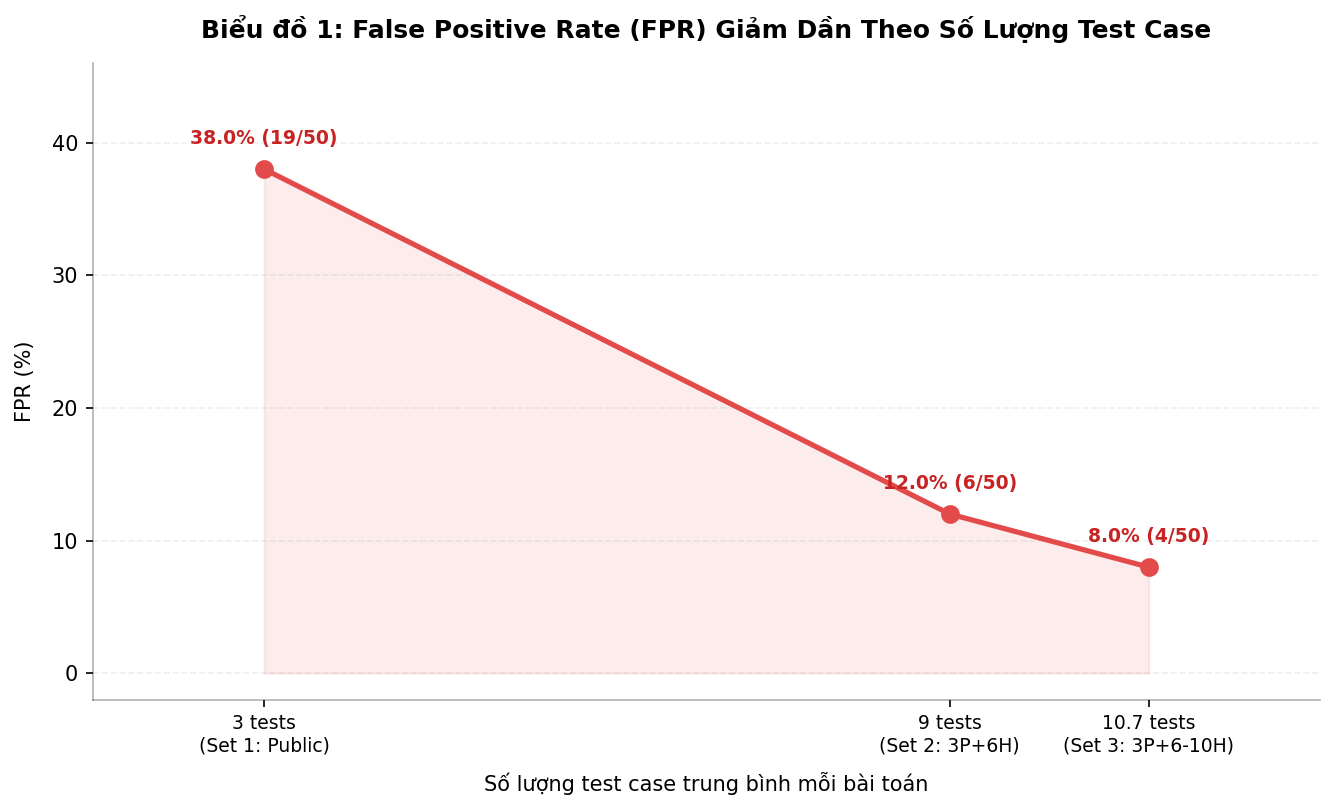


2. Phan phoi loi WA/RE/SE theo 3 bo test:


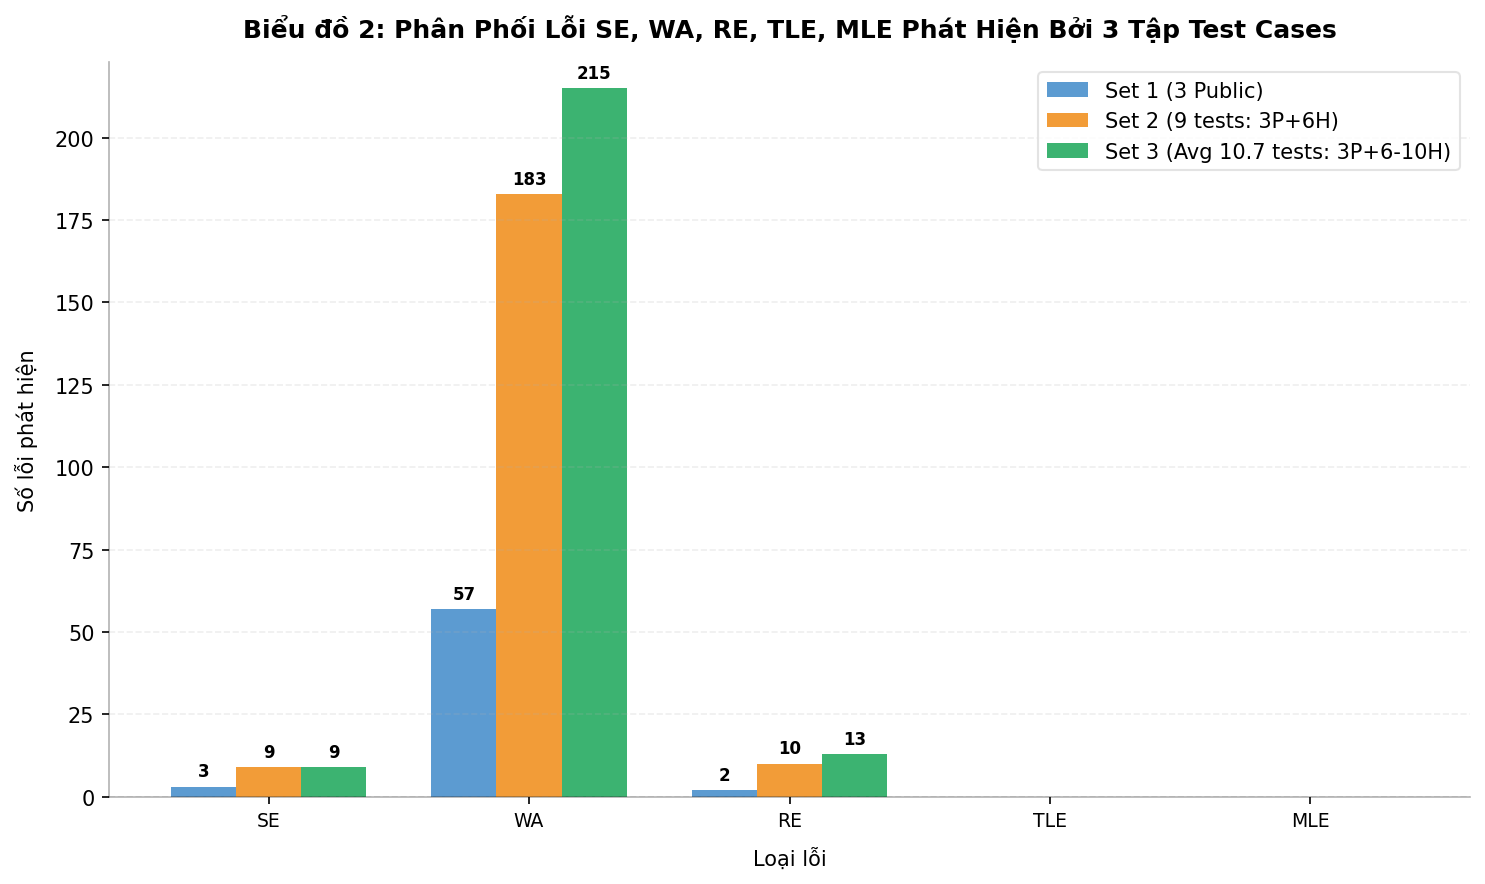


3. FPR theo chu de bai toan (fpr_by_topic):


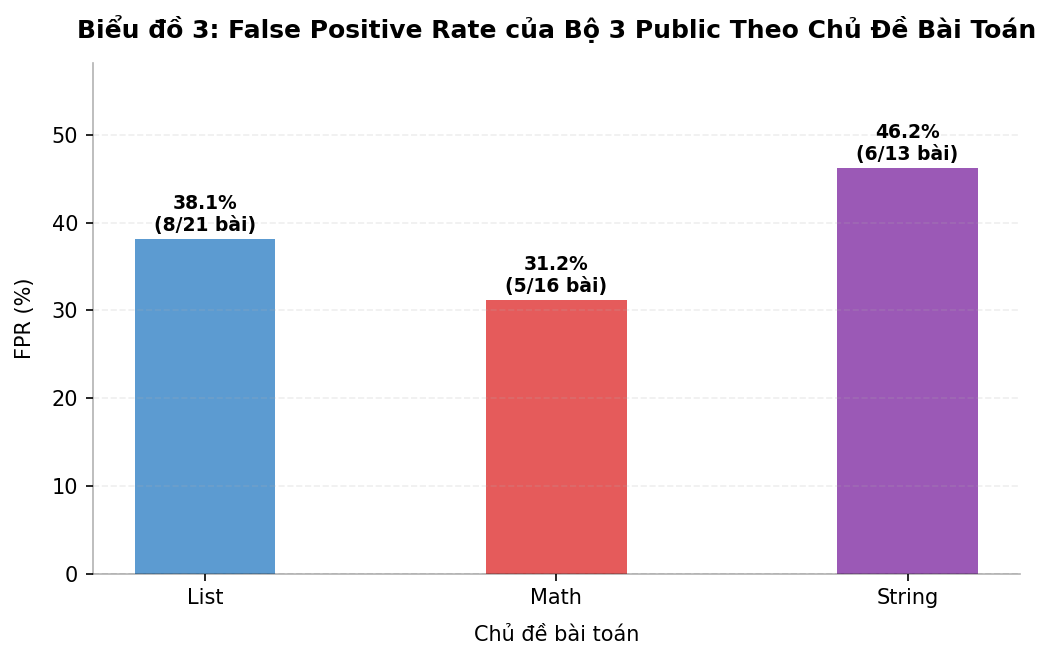

In [23]:
# Hien thi cac bieu do da luu
from IPython.display import Image, display

print('1. Duong cong FPR theo so test case (RQ1 Curve):')
display(Image(filename=str(BASE / 'results' / 'FPR_vs_ntest.png')))

print('\n2. Phan phoi loi WA/RE/SE theo 3 bo test:')
display(Image(filename=str(BASE / 'results' / 'error_types_comparison.png')))

# ✅ Đã sửa: comment đúng tên biểu đồ
print('\n3. FPR theo chu de bai toan (fpr_by_topic):')
display(Image(filename=str(BASE / 'results' / 'fpr_by_topic.png')))


#HIỂN THỊ KẾT QUẢ SO SÁNH

In [24]:
# Load ket qua so sanh va hien thi
import pandas as pd
df = pd.read_csv(BASE / 'results' / 'comparison_3sets.csv')
print("Mau bang so sanh chi tiet:")
df.head()

Mau bang so sanh chi tiet:


,sv_id,task_id,func,topic,mo_ta_loi,actual_error_type,set1_pass,set1_total,set1_tpr,is_fp_set1,set2_pass,set2_total,set2_tpr,is_fp_set2,set3_pass,set3_total,set3_tpr,is_fp_set3
0,SV001,1,sum_list,list,Cộng index thay vì giá trị — WA với mọi input,WA,0,3,0.00,False,2,9,22.22,False,2,9,22.22,False
1,SV002,1,sum_list,list,Quên return — trả None,WA,0,3,0.00,False,0,9,0.00,False,0,9,0.00,False
2,SV003,1,sum_list,list,Hard-code kết quả bài test đầu tiên,HC,3,3,100.00,True,6,9,66.67,False,6,9,66.67,False
3,SV004,2,is_even,math,Syntax Error — thiếu dấu :,CE,0,3,0.00,False,0,9,0.00,False,0,9,0.00,False
4,SV005,2,is_even,math,Luôn trả True — pass public test chẵn,WA,2,3,66.67,False,5,9,55.56,False,5,9,55.56,False


## FAULTY ACCEPTANCE RATE (FPR theo bài buggy)

Bổ sung theo yêu cầu GV: báo FP/bài buggy ngoài FP/tổng bài.

In [25]:
# ✅ Bổ sung: Faulty Acceptance Rate = FP / bài buggy (yêu cầu từ GV)
import pandas as pd, json
from pathlib import Path

BASE = Path('/content/drive/MyDrive/Project')
comp_json = BASE / 'results' / 'comparison_3sets.json'

# Tổng bài buggy (error_type != 'AC')
sub_file = BASE / 'data' / 'processed' / 'submissions_50_v2.json'
with open(sub_file, encoding='utf-8') as f:
    subs = json.load(f)
n_buggy = sum(1 for s in subs if s.get('error_type', '') != 'AC')
n_total = len(subs)
print(f'Tổng bài nộp: {n_total} | Bài buggy (≠AC): {n_buggy} | Bài AC: {n_total - n_buggy}')

if comp_json.exists():
    with open(comp_json, encoding='utf-8') as f:
        comp = json.load(f)
    stats = comp.get('stats', {})
    print('\n{:<20} {:>12} {:>15} {:>18}'.format('Bộ test', 'FP/tổng', 'FPR (tổng %)', 'FAR (FP/buggy %)'))
    print('-' * 68)
    for key, label in [('set1','Set1 – 3 public'), ('set2','Set2 – 3pub+6hid'), ('set3','Set3 – 3pub+6-10hid')]:
        s = stats.get(key, {})
        fp = s.get('fp_count', 0)
        fpr = s.get('fpr_pct', 0)
        far = round(fp / n_buggy * 100, 1) if n_buggy > 0 else 0
        print(f'{label:<20} {fp:>5}/{n_total:<6} {fpr:>12.1f}% {far:>16.1f}%')


Tổng bài nộp: 50 | Bài buggy (≠AC): 45 | Bài AC: 5

Bộ test                   FP/tổng    FPR (tổng %)   FAR (FP/buggy %)
--------------------------------------------------------------------
Set1 – 3 public         19/50             38.0%             42.2%
Set2 – 3pub+6hid         6/50             12.0%             13.3%
Set3 – 3pub+6-10hid      4/50              8.0%              8.9%


#LƯU DỮ LIỆU

In [26]:
DRIVE_OUT = f'/content/drive/MyDrive/Project/results'
os.makedirs(DRIVE_OUT, exist_ok=True)

RESULTS_DIR = os.path.join(BASE, 'results')

for f in ['comparison_3sets.csv', 'comparison_3sets.json']:
    src = os.path.join(RESULTS_DIR, f)
    dst = os.path.join(DRIVE_OUT, f)
    if os.path.abspath(src) != os.path.abspath(dst):
        shutil.copy(src, dst)
    print(f'✓ Lưu: {f}')

print('✓ Đã backup lên Drive')

✓ Lưu: comparison_3sets.csv
✓ Lưu: comparison_3sets.json
✓ Đã backup lên Drive


#BẢNG TỔNG HỢP LATENCY BASELINE

In [27]:
# Auto-load df_bl neu chua chay Buoc 3
if 'df_bl' not in dir() or df_bl is None:
    _bl_csv = BASE / 'results' / 'baseline_summary.csv'
    if _bl_csv.exists():
        df_bl = pd.read_csv(_bl_csv)
    else:
        print('Chua co baseline_summary.csv — Hay chay Buoc 2 truoc')
        df_bl = None

# Load comparison_3sets.json de lay FPR
comp_json = BASE / 'results' / 'comparison_3sets.json'
if comp_json.exists() and df_bl is not None:
    with open(comp_json, encoding='utf-8') as f:
        comp = json.load(f)
    stats = comp.get('stats', {})

    rows = []
    for key, label in [('set1', 'Set1_3pub'), ('set2', 'Set2_3P6H'), ('set3', 'Set3_3P6-10H')]:
        s = stats.get(key, {})
        rows.append({
            'Bo_test'   : label,
            'FP_count'  : s.get('fp_count', '-'),
            'FPR_pct'   : s.get('fpr_pct', '-'),
            'Avg_TPR'   : s.get('avg_tpr', '-'),
            'Latency_s' : s.get('avg_latency', '-'),
        })

    rows.insert(0, {
        'Bo_test'   : 'Baseline_AC',
        'FP_count'  : 0,
        'FPR_pct'   : 0.0,
        'Avg_TPR'   : 100.0,
        'Latency_s' : round(df_bl['avg_latency_total'].mean(), 4),
    })

    df_compare = pd.DataFrame(rows).set_index('Bo_test')

    # Format thu cong, khong can jinja2
    df_fmt = df_compare.copy()
    df_fmt['FPR_pct']   = df_fmt['FPR_pct'].apply(lambda x: f'{x:.1f}%' if isinstance(x, (int, float)) else x)
    df_fmt['Avg_TPR']   = df_fmt['Avg_TPR'].apply(lambda x: f'{x:.1f}%' if isinstance(x, (int, float)) else x)
    df_fmt['Latency_s'] = df_fmt['Latency_s'].apply(lambda x: f'{x:.4f}s' if isinstance(x, (int, float)) else x)

    print('So sanh Baseline vs Bai nop sinh vien theo 3 bo test:')
    display(df_fmt)
elif df_bl is None:
    print('Khong co du lieu baseline — vui long chay Buoc 2 truoc')
else:
    print('Chua co comparison_3sets.json — Chay comparison_3sets.py truoc')


So sanh Baseline vs Bai nop sinh vien theo 3 bo test:


,FP_count,FPR_pct,Avg_TPR,Latency_s
Bo_test,,,,
Baseline_AC,0,0.0%,100.0%,0.3573s
Set1_3pub,19,38.0%,58.7%,0.0434s
Set2_3P6H,6,12.0%,55.1%,0.0440s
Set3_3P6-10H,4,8.0%,55.5%,0.0446s
